# RESD Dataset — Exploratory Data Analysis
Russian Emotional Speech Dataset (7 emotions, ~1400 samples)

Columns: `emotion`, `speech` (AudioDecoder via torchcodec or legacy dict)

In [2]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'datasets', 'torchaudio', 'matplotlib', 'seaborn', 'soundfile'], check=True)

CompletedProcess(args=['/Users/aleksandr/GitReps/speech_emo_finetune/.venv/bin/python', '-m', 'pip', 'install', '-q', 'datasets', 'torchaudio', 'matplotlib', 'seaborn', 'soundfile'], returncode=0)

In [3]:
import collections
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torchaudio
import torchaudio.transforms as T
from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
SAMPLE_RATE = 16_000

ds = load_dataset('Aniemore/resd')
print(ds)

DatasetDict({
    train: Dataset({
        features: ['name', 'path', 'emotion', 'speech'],
        num_rows: 1116
    })
    test: Dataset({
        features: ['name', 'path', 'emotion', 'speech'],
        num_rows: 280
    })
})


In [4]:
def decode_audio(speech_field):
    """Return (waveform: float32 1D tensor, sample_rate: int).
    Handles torchcodec AudioDecoder and legacy dict.
    """
    try:
        samples = speech_field.get_all_samples()
        waveform = samples.data  # (channels, time)
        if waveform.ndim > 1:
            waveform = waveform.mean(dim=0)
        return waveform.float(), int(samples.sample_rate)
    except AttributeError:
        return torch.tensor(speech_field['array'], dtype=torch.float32), speech_field['sampling_rate']

# smoke test
ex0 = ds['train'][0]
w, sr = decode_audio(ex0['speech'])
print(f"emotion={ex0['emotion']}  waveform shape={w.shape}  sr={sr}  duration={w.shape[0]/sr:.2f}s")

emotion=happiness  waveform shape=torch.Size([82211])  sr=16000  duration=5.14s


## Class distribution

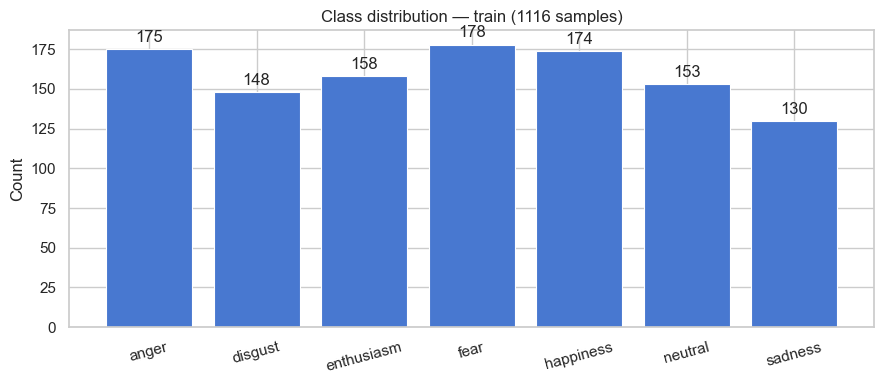

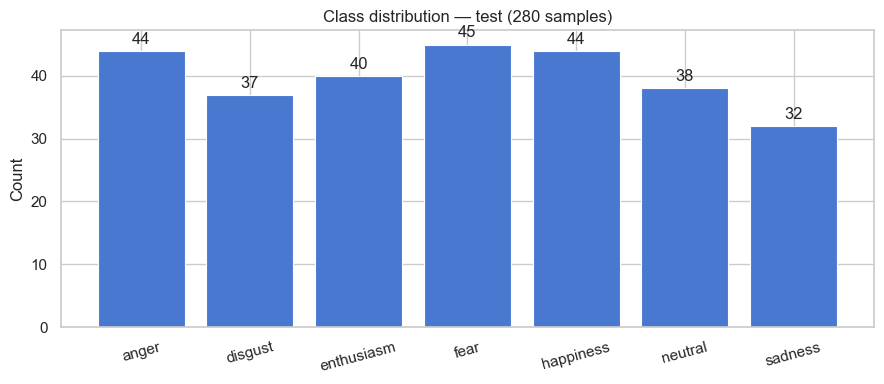

In [5]:
for split in ['train', 'test']:
    labels = [ex['emotion'] for ex in ds[split]]
    counts = collections.Counter(labels)
    classes = sorted(counts.keys())
    vals = [counts[c] for c in classes]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(classes, vals, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, padding=3)
    ax.set_title(f'Class distribution — {split} ({sum(vals)} samples)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()

## Audio duration distribution

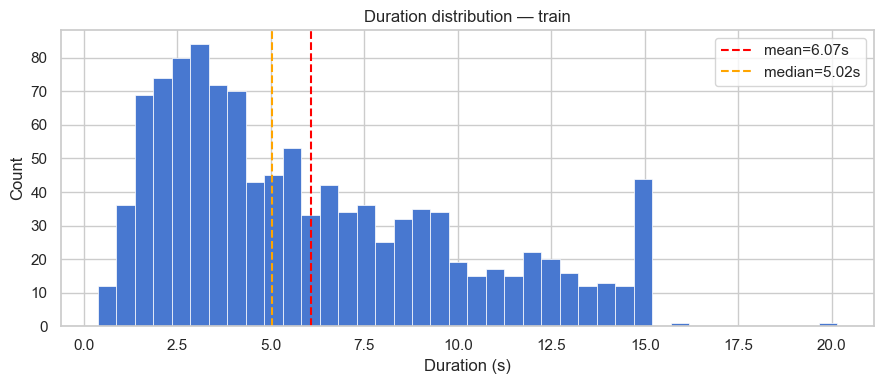

train: min=0.37s  max=20.14s  mean=6.07s


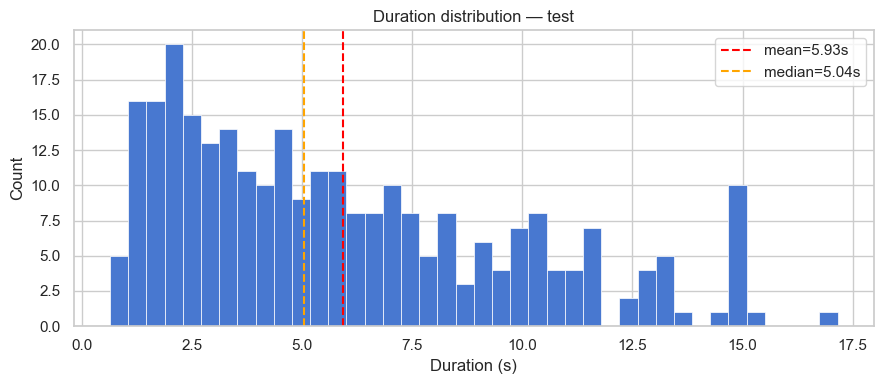

test: min=0.64s  max=17.16s  mean=5.93s


In [6]:
for split in ['train', 'test']:
    durations = []
    for ex in ds[split]:
        w, sr = decode_audio(ex['speech'])
        durations.append(w.shape[0] / sr)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(durations, bins=40, edgecolor='white', linewidth=0.5)
    ax.axvline(np.mean(durations), color='red', linestyle='--', label=f'mean={np.mean(durations):.2f}s')
    ax.axvline(np.median(durations), color='orange', linestyle='--', label=f'median={np.median(durations):.2f}s')
    ax.set_title(f'Duration distribution — {split}')
    ax.set_xlabel('Duration (s)')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'{split}: min={min(durations):.2f}s  max={max(durations):.2f}s  mean={np.mean(durations):.2f}s')

## Duration per class (boxplot)

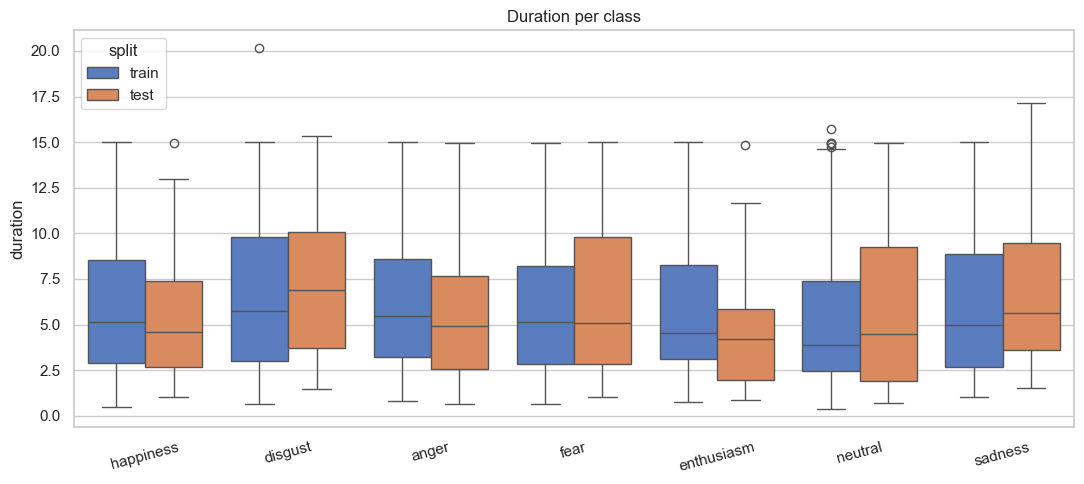

In [7]:
rows = []
for split in ['train', 'test']:
    for ex in ds[split]:
        w, sr = decode_audio(ex['speech'])
        rows.append({'emotion': ex['emotion'], 'duration': w.shape[0] / sr, 'split': split})
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='emotion', y='duration', hue='split', ax=ax)
ax.set_title('Duration per class')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Sample rates

In [8]:
for split in ['train', 'test']:
    srs = collections.Counter()
    for ex in ds[split]:
        _, sr = decode_audio(ex['speech'])
        srs[sr] += 1
    print(f'{split} sample rates:', dict(srs))

train sample rates: {16000: 565, 44100: 551}
test sample rates: {44100: 129, 16000: 151}


## Train / Dev / Test split sizes

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

LABEL2ID = {'happiness':0,'sadness':1,'anger':2,'fear':3,'disgust':4,'enthusiasm':5,'neutral':6}
ID2LABEL = {v:k for k,v in LABEL2ID.items()}
DEV_RATIO = 0.15
SEED = 42

labels = [LABEL2ID[ex['emotion']] for ex in ds['train']]
sss = StratifiedShuffleSplit(n_splits=1, test_size=DEV_RATIO, random_state=SEED)
train_idx, dev_idx = next(sss.split(np.arange(len(ds['train'])), labels))

print(f'Train:  {len(train_idx)}')
print(f'Dev:    {len(dev_idx)}')
print(f'Test:   {len(ds["test"])}')

dev_labels = [labels[i] for i in dev_idx]
dev_counts = collections.Counter(dev_labels)
print('\nDev class distribution:')
for cid, cnt in sorted(dev_counts.items()):
    print(f'  {ID2LABEL[cid]:12s} {cnt}')

Train:  948
Dev:    168
Test:   280

Dev class distribution:
  happiness    26
  sadness      20
  anger        26
  fear         27
  disgust      22
  enthusiasm   24
  neutral      23


## Example waveform per class

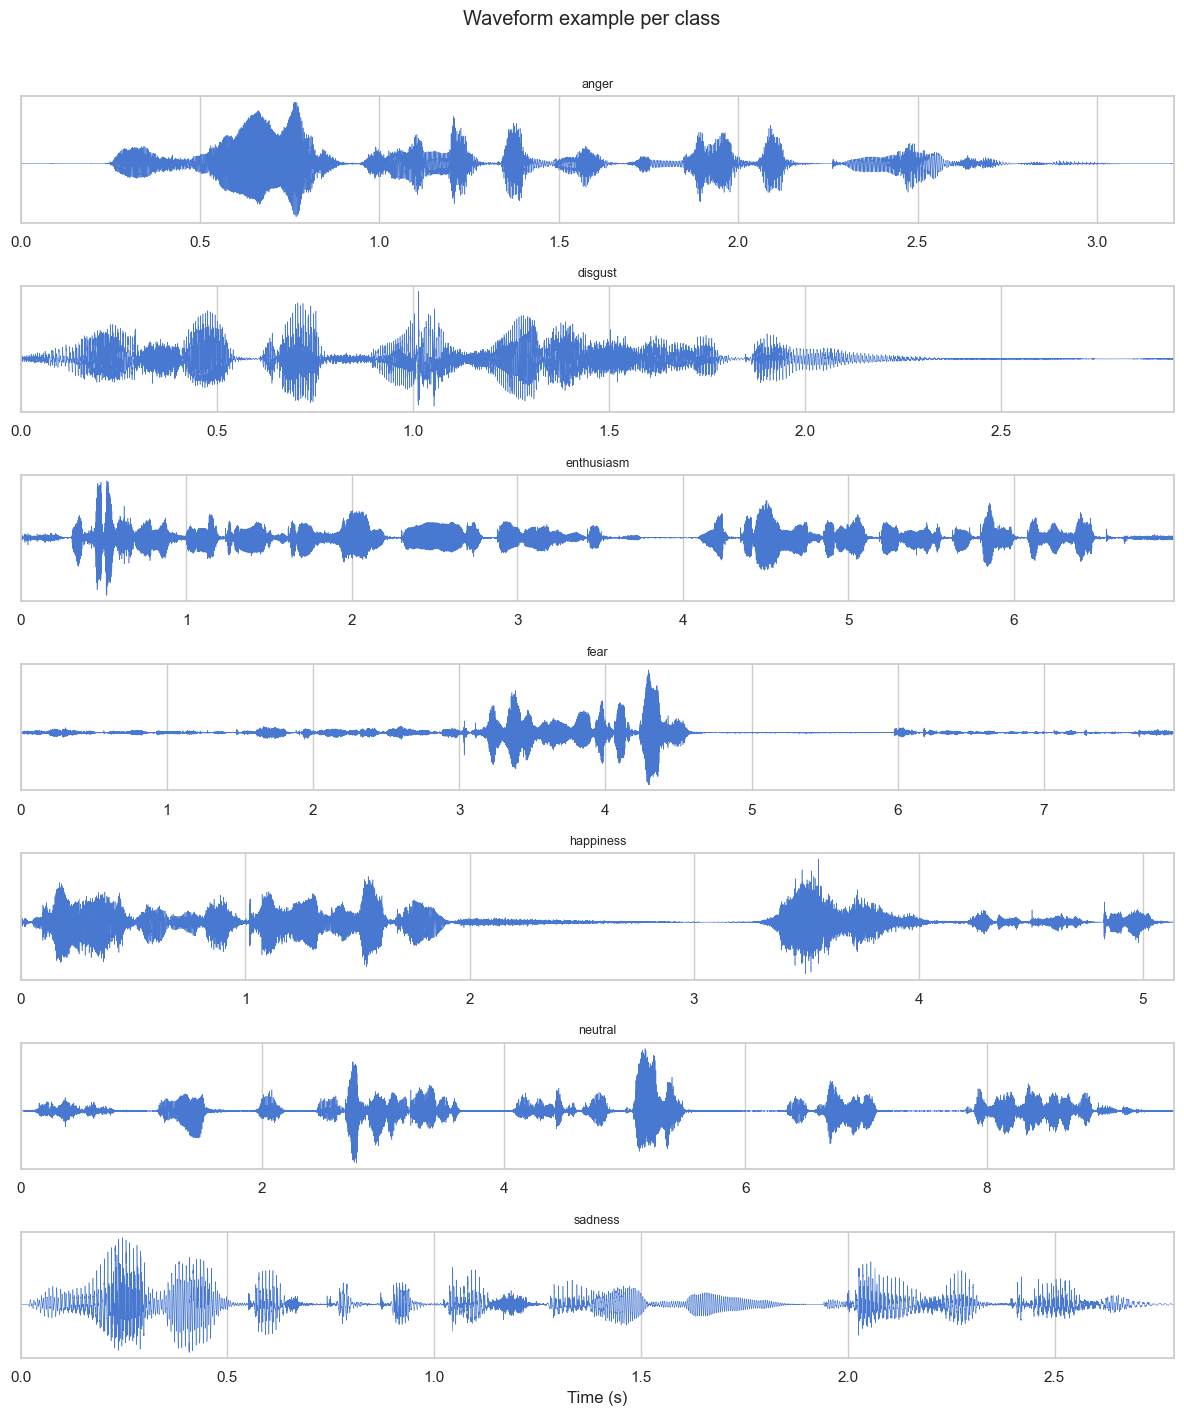

Playing: anger


In [10]:
by_class = {}
for ex in ds['train']:
    lbl = ex['emotion']
    if lbl not in by_class:
        by_class[lbl] = ex

n_classes = len(by_class)
fig, axes = plt.subplots(n_classes, 1, figsize=(12, 2 * n_classes))

for ax, (lbl, ex) in zip(axes, sorted(by_class.items())):
    waveform, sr = decode_audio(ex['speech'])
    t = torch.linspace(0, waveform.shape[0] / sr, waveform.shape[0])
    ax.plot(t.numpy(), waveform.numpy(), linewidth=0.4)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlim(0, t[-1].item())
    ax.set_yticks([])

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Waveform example per class', y=1.01)
plt.tight_layout()
plt.show()

# Audio player
ex0_lbl = sorted(by_class.keys())[0]
ex0_wave, ex0_sr = decode_audio(by_class[ex0_lbl]['speech'])
print('Playing:', ex0_lbl)
ipd.display(ipd.Audio(ex0_wave.numpy(), rate=ex0_sr))

## Mel spectrograms per class

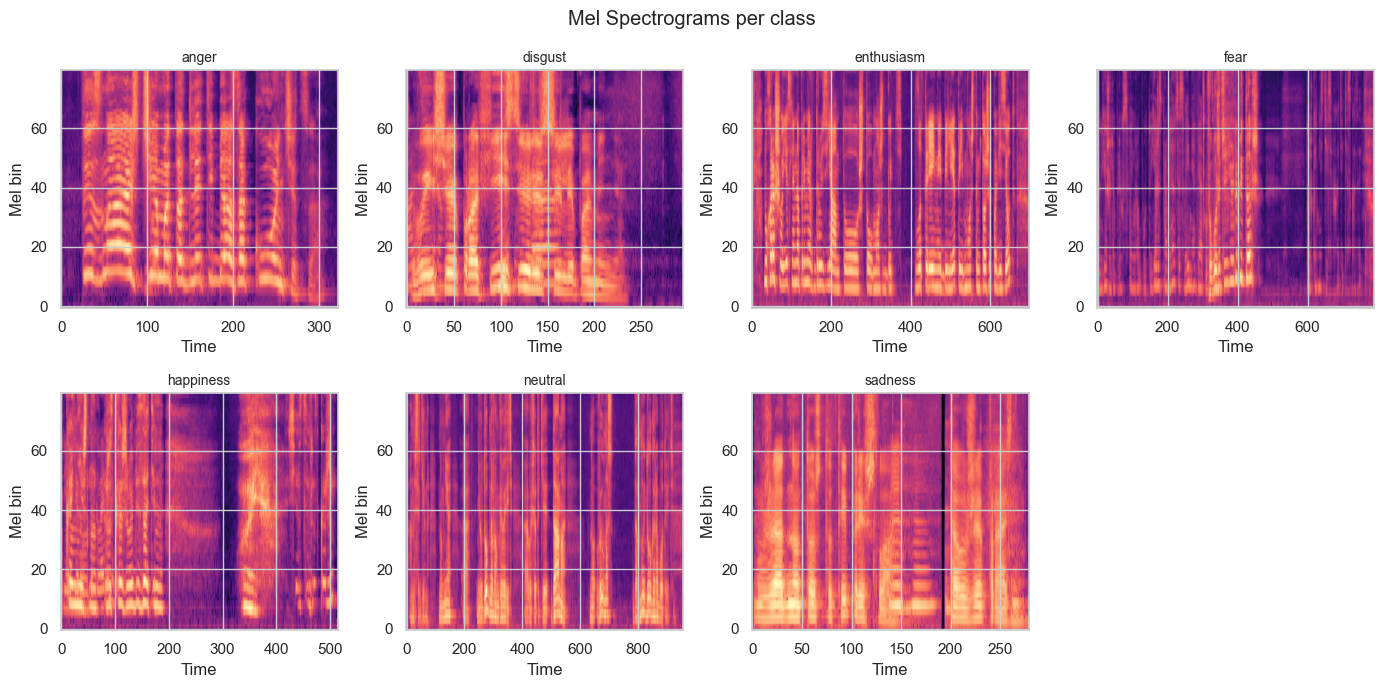

In [11]:
mel_transform = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=400, hop_length=160, n_mels=80)
db_transform = T.AmplitudeToDB()

n_cols = 4
n_rows = (n_classes + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for i, (lbl, ex) in enumerate(sorted(by_class.items())):
    waveform, sr = decode_audio(ex['speech'])
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform.unsqueeze(0), sr, SAMPLE_RATE).squeeze(0)
    mel = db_transform(mel_transform(waveform.unsqueeze(0))).squeeze(0)
    axes[i].imshow(mel.numpy(), origin='lower', aspect='auto', cmap='magma')
    axes[i].set_title(lbl, fontsize=10)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Mel bin')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Mel Spectrograms per class')
plt.tight_layout()
plt.show()

## Augmentation preview

Original vs augmented audio + waveform overlay for each augmentation type.

Emotion: happiness  |  duration: 5.00s


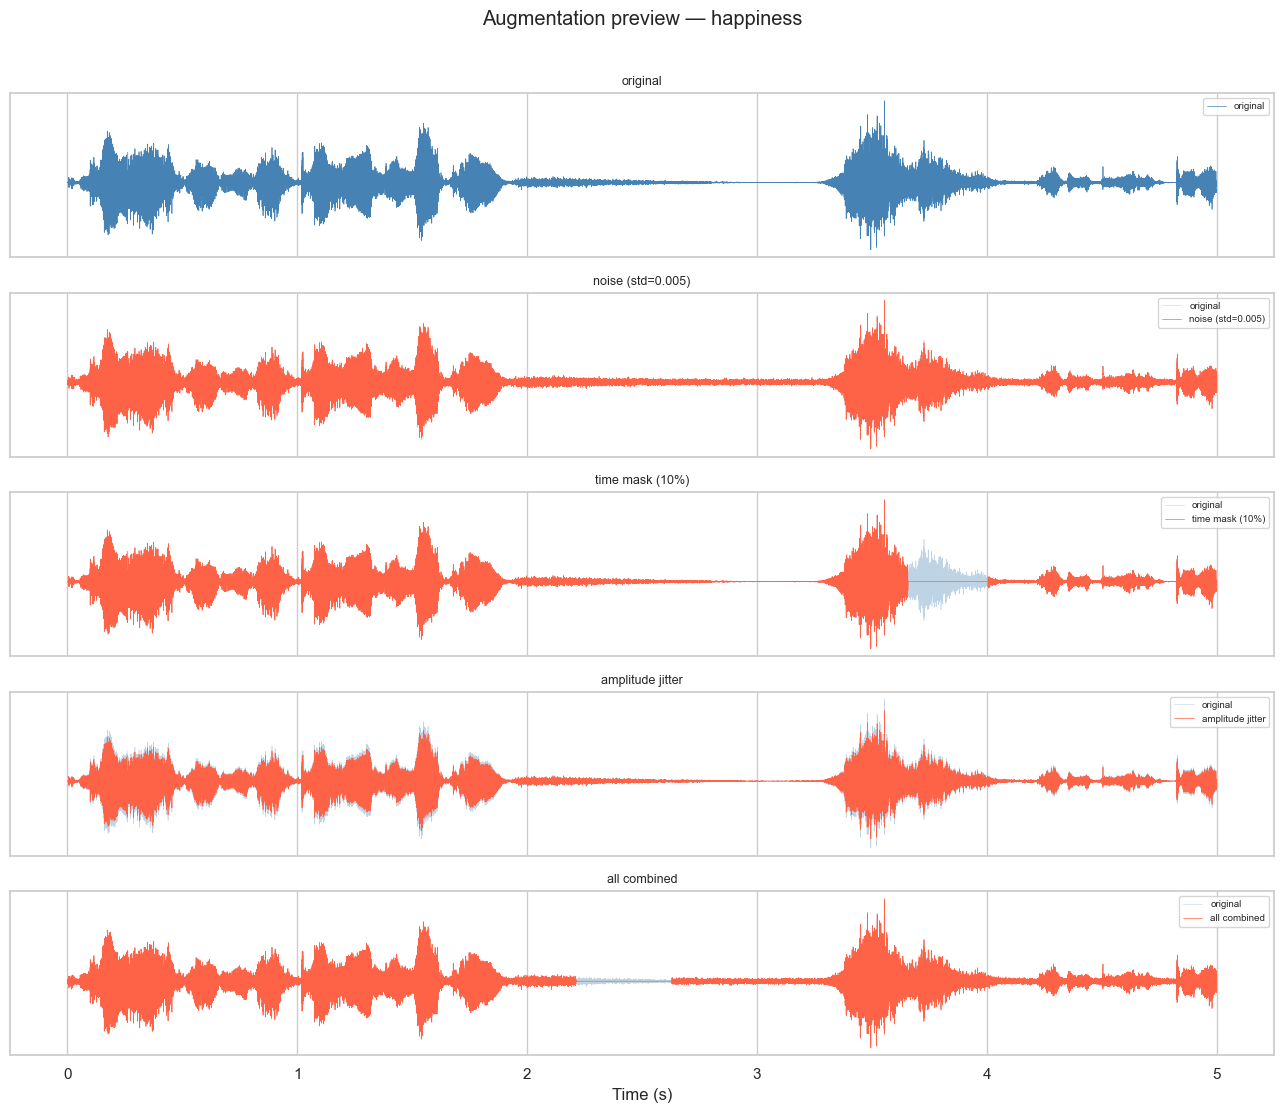


Listen to each version:

▶ original



▶ noise (std=0.005)



▶ time mask (10%)



▶ amplitude jitter



▶ all combined


In [12]:
import torchaudio.functional as AF

# Pick one sample
ex = ds['train'][0]
waveform, sr = decode_audio(ex['speech'])
if sr != SAMPLE_RATE:
    waveform = AF.resample(waveform.unsqueeze(0), sr, SAMPLE_RATE).squeeze(0)
waveform = waveform[:SAMPLE_RATE * 5]  # first 5 seconds
print(f"Emotion: {ex['emotion']}  |  duration: {waveform.shape[0]/SAMPLE_RATE:.2f}s")

# --- augmentation functions (mirrors src/dataset.py) ---
def aug_noise(w, std=0.005):
    return (w + torch.randn_like(w) * std).clamp(-1, 1)

def aug_time_mask(w, ratio=0.1):
    w = w.clone()
    T = w.shape[0]
    mask_len = int(T * ratio * torch.rand(1).item())
    if mask_len > 0:
        start = torch.randint(0, max(1, T - mask_len), (1,)).item()
        w[start:start + mask_len] = 0.0
    return w

def aug_amplitude(w, lo=0.8, hi=1.2):
    scale = lo + (hi - lo) * torch.rand(1).item()
    return (w * scale).clamp(-1, 1)

def aug_all(w):
    return aug_amplitude(aug_time_mask(aug_noise(w)))

augmentations = {
    'original':          waveform,
    'noise (std=0.005)': aug_noise(waveform),
    'time mask (10%)':   aug_time_mask(waveform),
    'amplitude jitter':  aug_amplitude(waveform),
    'all combined':      aug_all(waveform),
}

# --- plot waveforms ---
fig, axes = plt.subplots(len(augmentations), 1, figsize=(13, 2.2 * len(augmentations)), sharex=True)
t = np.linspace(0, waveform.shape[0] / SAMPLE_RATE, waveform.shape[0])

for ax, (name, w) in zip(axes, augmentations.items()):
    if name == 'original':
        ax.plot(t, w.numpy(), linewidth=0.5, color='steelblue', label='original')
    else:
        ax.plot(t, waveform.numpy(), linewidth=0.4, color='steelblue', alpha=0.35, label='original')
        ax.plot(t, w.numpy(), linewidth=0.5, color='tomato', label=name)
    ax.set_title(name, fontsize=9)
    ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=7)

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Augmentation preview — {ex["emotion"]}', y=1.01)
plt.tight_layout()
plt.show()

# --- audio players ---
print('\nListen to each version:')
for name, w in augmentations.items():
    print(f'\n▶ {name}')
    ipd.display(ipd.Audio(w.numpy(), rate=SAMPLE_RATE))